# Title: Historical Stock Revenue Analysis ( Tesla and GameStop )

**Author:** Amina Tahir  
**Project:** IBM Data Science Professional Certificate ( python for Data science) — Final Assignment  

---

## 📌 Abstract
This project analyzes the financial history of Tesla and GameStop by downloading historical stock market data and scraping quarterly revenue tables from web pages. After cleaning and organizing the data, it generates clear comparison charts to examine long-term growth trends and market performance.

---

## 🛠️ Tools & Technologies Used
* **Python**: Core programming language.
* **Pandas**: Used for data manipulation, cleaning, and structuring dataframes.
* **yfinance**: Used for fetching historical stock market data.
* **BeautifulSoup & Requests**: Used for web scraping quarterly revenue data from web pages.
* **Matplotlib**: Used for rendering comparison graphs.
* **Google Colab**: Cloud-based notebook environment.

---

## 📑 Table of Contents
1. Extracting Tesla Stock Data Using `yfinance`
2. Scraping Tesla Revenue Data Using `BeautifulSoup`
3. Extracting GameStop Stock Data Using `yfinance`
4. Scraping GameStop Revenue Data Using `BeautifulSoup`
5. Data Cleaning and Preprocessing
6. Plotting and Visualizing Historical Trends
___

# Extracting Tesla Stock Data Using yfinance
We use the `yfinance` library to download historical stock market data for Tesla (TSLA) with maximum history, reset the index, and display the first five rows.

In [2]:
import yfinance as yf
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


### Step 1: Downloading the Webpage Content
We use the `requests` library to fetch the HTML contents of the Tesla revenue webpage using the provided URL.

In [3]:
!pip install requests
import requests
response=requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm")
html_data=response.text

### Step 2: Parse HTML and Locate Tables
We initialize a BeautifulSoup object and use Pandas `read_html` to extract and inspect the table structures, identifying that table index `[1]` holds the quarterly revenue data.

In [4]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(html_data,"html.parser")

In [5]:
# Check the total number of table bodies (<tbody>) on the webpage to identify which table contains the required quarterly revenue data
print(len(soup.find_all("tbody")))

6


In [6]:
# we want to check which table hold quarterly data
import pandas as pd
tables=pd.read_html(html_data)
print(tables[0].head(2))
print(tables[1].head(2))


   Tesla Annual Revenue (Millions of US $)  \
0                                     2021   
1                                     2020   

  Tesla Annual Revenue (Millions of US $).1  
0                                   $53,823  
1                                   $31,536  
  Tesla Quarterly Revenue (Millions of US $)  \
0                                 2022-09-30   
1                                 2022-06-30   

  Tesla Quarterly Revenue (Millions of US $).1  
0                                      $21,454  
1                                      $16,934  


/tmp/ipykernel_641/1328666867.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables=pd.read_html(html_data)


### Step 3: Clean the Data and Display the Tail
We assign clean column names ("Date" and "Revenue"), strip out commas and dollar signs using regular expressions, drop empty rows, and display the final `.tail()` results.

In [7]:
# Select the quarterly revenue table and rename the columns
tesla_revenue=tables[1]
tesla_revenue.columns=["Date", "Revenue"]

In [8]:
#Clean the Revenue column
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r',|\$', "", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

#Display the last 5 rows
print(tesla_revenue.tail())

          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


# Extracting GameStop Stock Data Using yfinance
We use the `yfinance` library to download historical stock market data for GameStop(GME) with maximum history, reset the index, and display the first five rows.

In [9]:
gme=yf.Ticker("GME")
gme_data=gme.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


### Step 1: Download and Parse GameStop Webpage Content
We use the `requests` library to fetch the HTML contents of the GameStop revenue webpage and initialize a BeautifulSoup object to parse it.

In [10]:
response=requests.get(" https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html")
gme_html_data=response.text
soup=BeautifulSoup(gme_html_data,"html.parser")

### Step 2: Check Table Bodies Count
We check how many table body tags exist on the webpage to understand its layout structure.

In [11]:
print(len(soup.find_all("tbody")))

6


### Step 3: Inspect Tables to Locate Quarterly Data
We use Pandas `read_html` to read all tables on the page and print the first few rows of tables `0` and `1` to identify which one contains the quarterly revenue.

In [12]:
tables=pd.read_html(gme_html_data)
print(tables[0].head(2))
print(tables[1].head(2))

   GameStop Annual Revenue (Millions of US $)  \
0                                        2020   
1                                        2019   

  GameStop Annual Revenue (Millions of US $).1  
0                                       $6,466  
1                                       $8,285  
  GameStop Quarterly Revenue (Millions of US $)  \
0                                    2020-04-30   
1                                    2020-01-31   

  GameStop Quarterly Revenue (Millions of US $).1  
0                                          $1,021  
1                                          $2,194  


/tmp/ipykernel_641/1541608777.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables=pd.read_html(gme_html_data)


### Step 4: Select, Clean, and Display GameStop Quarterly Revenue
We isolate the quarterly table, rename the columns to "Date" and "Revenue", clean out dollar signs and commas, drop empty rows, and display the final `.tail()` results.

In [13]:
# we need quarterly table
gme_revenue=tables[1]
gme_revenue.columns=["Date","Revenue"]
#Clean the Revenue column
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r',|\$', "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

#Display the last 5 rows
print(gme_revenue.tail())

          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


### Final Step: Plotting Tesla and GameStop Stock and Revenue Graphs
We define and call the graphing function to visualize the historical stock prices and revenue trends side-by-side.

In [1]:
# # We use 'matplotlib.pyplot' instead of 'plotly' for two reasons:
# 1. SIMPLICITY: .pyplot is a 'shortcut' module that makes drawing charts very easy.
# 2. COMPATIBILITY: It creates static (non-moving) images.
#We use Matplotlib for static images because they are much more reliable; they are guaranteed to be visible to graders, whereas interactive Plotly graphs often show up as blank boxes during submission. These "picture" style graphs are also lighter, faster, and work on every computer without technical bugs.
!pip install matplotlib
import matplotlib.pyplot as plt
# define a function and also these dates are specifically asked in the assignment that's why i use these specific dates
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
# sharex = True makes both graphs use the same Date line at the bottom
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    #axes[0] for the top graph and axes[1] for the bottom graph
    # Plot the line: (X-axis, Y-axis, Label name, Color)
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")  # Title at the top
    # display legend
    axes[0].legend()

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")
    axes[1].legend()

    plt.tight_layout() # Automatically adjusts spacing so titles don't overlap
    plt.show()

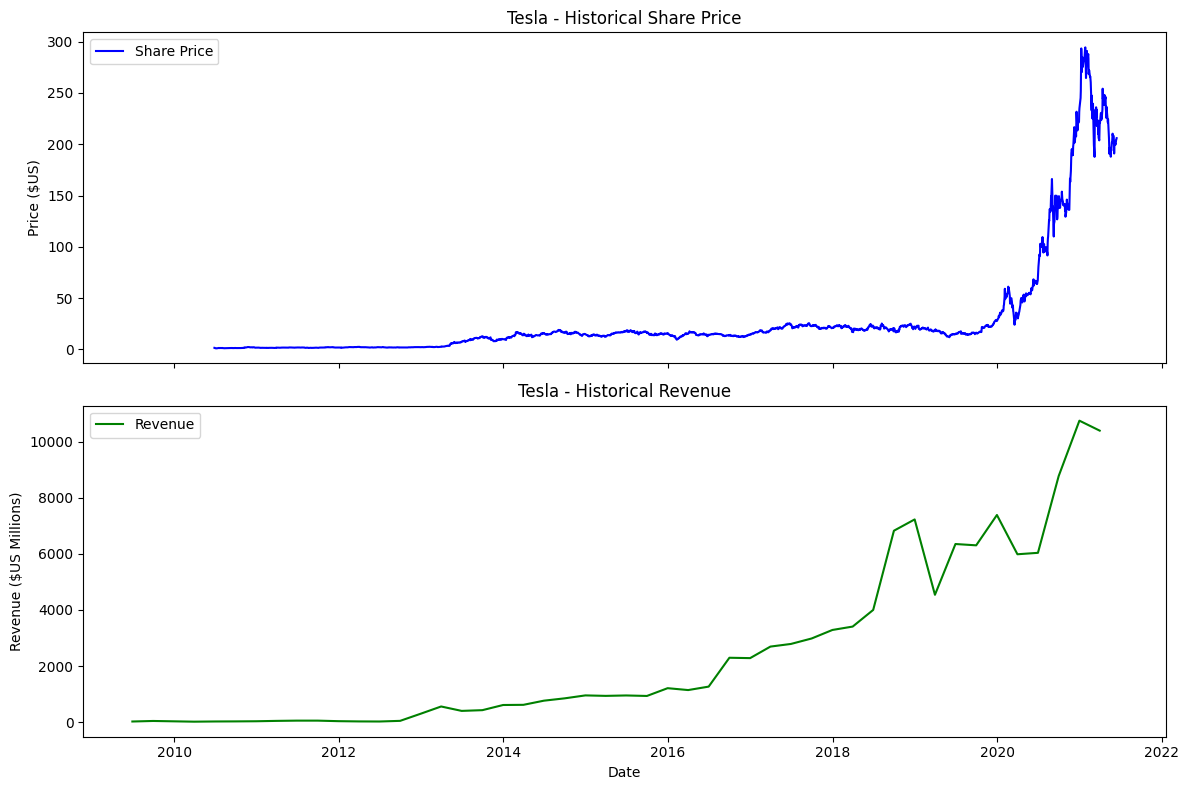

In [14]:
# Generate Tesla Graph
make_graph(tesla_data, tesla_revenue, 'Tesla')

### Key Observations

* **Upward Growth Trend:** Both Tesla's stock price and quarterly revenue exhibit a strong upward trajectory over the years, showing significant business expansion from 2010 to 2021.
* **Rapid Acceleration (2019–2021):** Starting around 2019, both graphs show a dramatic, steep spike upward, indicating a period of massive growth in both financial performance and market valuation.
* **Positive Correlation:** There is a visible relationship between revenue growth and stock price increases; as the company's quarterly revenue scaled into the billions, its stock price experienced a corresponding surge.

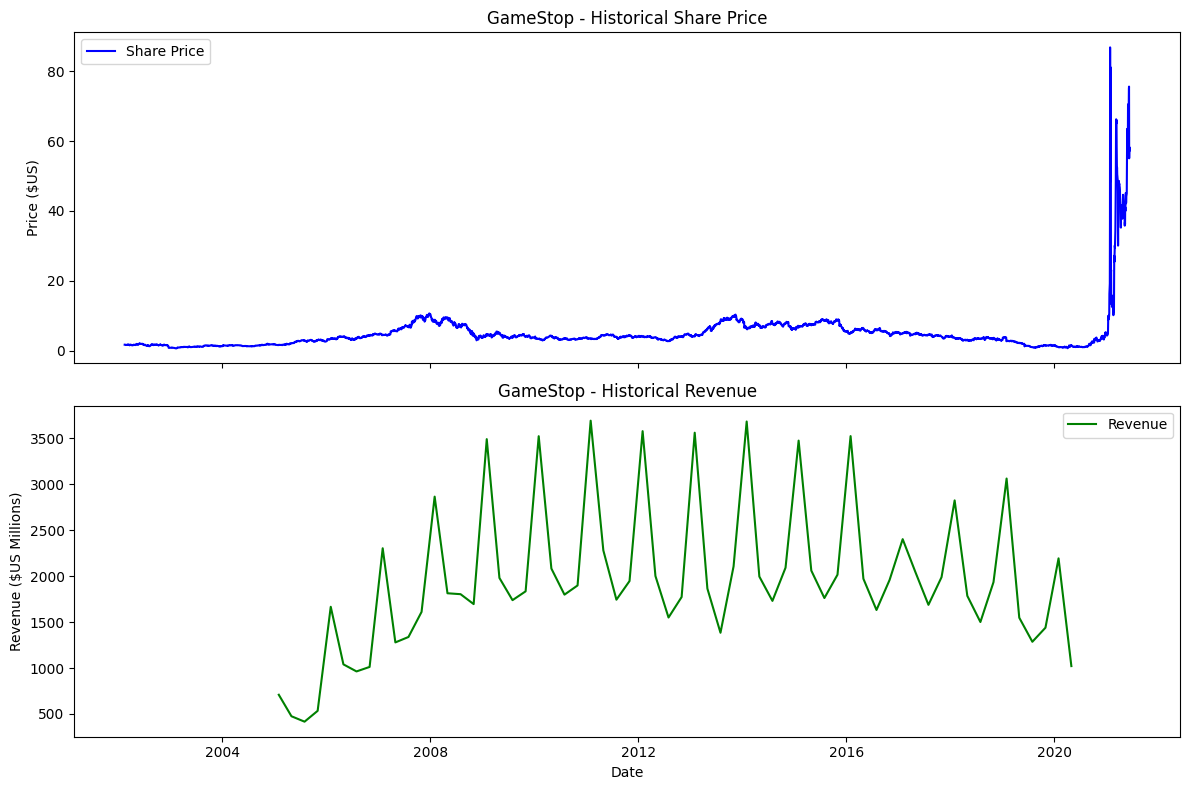

In [15]:
# Generate GameStop Graph
make_graph(gme_data, gme_revenue, 'GameStop')

### Key Observations

* **High Seasonality in Revenue:** Unlike Tesla's steady climb, GameStop's quarterly revenue (bottom graph) displays a very distinct, repeating wave pattern every single year, showing major spikes during holiday shopping seasons followed by predictable drops.
* **Massive Stock Surge (2020–2021):** The stock price (top graph) remains relatively flat and low for over a decade, followed by an unprecedented, explosive vertical spike around late 2020 and early 2021 (the famous retail trading wave).
* **Divergence:** While revenue fluctuated cyclically within a consistent range over the years, the stock price experienced a dramatic explosion that was detached from traditional quarterly revenue scaling.